# Análise de Crédito com K-Means

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [29]:
# Carregando o dataset de crédito
df = pd.read_csv('credito.csv')

# Exibindo as primeiras linhas para entender a estrutura
display(df.head())

# Verificando as informações das colunas
df.info()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    int64  
 1   Age             690 non-null    float64
 2   Debt            690 non-null    float64
 3   Married         690 non-null    int64  
 4   BankCustomer    690 non-null    int64  
 5   Industry        690 non-null    object 
 6   Ethnicity       690 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    int64  
 9   Employed        690 non-null    int64  
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    int64  
 12  Citizen         690 non-null    object 
 13  ZipCode         690 non-null    int64  
 14  Income          690 non-null    int64  
 15  Approved        690 non-null    int64  
dtypes: float64(3), int64(10), object(3)
memory usage: 86.4+ KB


In [30]:
# Removendo a coluna ZipCode
if 'ZipCode' in df.columns:
    df = df.drop('ZipCode', axis=1)

# Codificando colunas categóricas
colunas_categoricas = ['Industry', 'Ethnicity', 'Citizen']
le = LabelEncoder()
for col in colunas_categoricas:
    df[col] = le.fit_transform(df[col].astype(str))

display(df.head())

# Normalizando os dados
scaler = StandardScaler()
df_normalizado = scaler.fit_transform(df)

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,Income,Approved
0,1,30.83,0.000,1,1,7,4,1.25,1,1,1,0,0,0,1
1,0,58.67,4.460,1,1,9,1,3.04,1,1,6,0,0,560,1
2,0,24.50,0.500,1,1,9,1,1.50,1,0,0,0,0,824,1
3,1,27.83,1.540,1,1,7,4,3.75,1,1,5,1,0,3,1
4,1,20.17,5.625,1,1,7,4,1.71,1,0,0,0,1,0,1


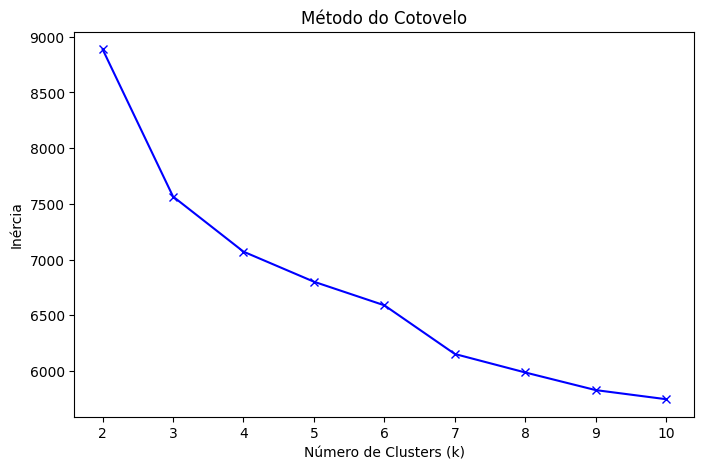

In [31]:
inercia = []
K = range(2, 11) # Testando K de 2 a 10

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_normalizado)
    inercia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inercia, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.show()

Analisando o gráfico acima, o "cotovelo" parece ocorrer ao redor de **k=4** ou **k=5**

In [32]:
# Instanciando e treinando o K-Means com k=4
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(df_normalizado)

# Adicionando a coluna de Grupo ao DataFrame original
df['Grupo'] = kmeans.labels_
display(df)

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,Income,Approved,Grupo
0,1,30.83,0.000,1,1,7,4,1.25,1,1,1,0,0,0,1,3
1,0,58.67,4.460,1,1,9,1,3.04,1,1,6,0,0,560,1,2
2,0,24.50,0.500,1,1,9,1,1.50,1,0,0,0,0,824,1,3
3,1,27.83,1.540,1,1,7,4,3.75,1,1,5,1,0,3,1,3
4,1,20.17,5.625,1,1,7,4,1.71,1,0,0,0,1,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1,21.08,10.085,0,0,3,1,1.25,0,0,0,0,0,0,0,1
686,0,22.67,0.750,1,1,4,4,2.00,0,1,2,1,0,394,0,0
687,0,25.25,13.500,0,0,6,2,2.00,0,1,1,1,0,1,0,1
688,1,17.92,0.205,1,1,2,4,0.04,0,0,0,0,0,750,0,0


In [33]:
# Agrupando pelo cluster para ver as médias das características numéricas principais
medias_grupos = df.groupby('Grupo').mean()
display(medias_grupos[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']])

,Age,Debt,YearsEmployed,CreditScore,Income
Grupo,,,,,
0,29.696705,3.454559,0.937280,0.509579,235.206897
1,28.981813,3.826719,1.580594,0.931250,468.056250
2,48.038659,10.890549,7.830244,8.939024,2049.000000
3,28.971337,4.687594,2.109866,3.427807,2126.737968



A partir das médias, podemos observar:
*   **Grupo 0**: Costumam ter renda mais baixa e score de crédito muito baixo. A dívida (Debt) e o tempo de emprego (YearsEmployed) são intermediários.
*   **Grupo 1**: Representam um perfil mais jovem, com tempo de emprego e score de crédito consideravelmente baixos, além de renda bem baixa.
*   **Grupo 2**: Têm um score de crédito mais alto e tempo de emprego elevado. É o grupo com o melhor perfil geral.
*   **Grupo 3**: Têm a renda mais alta de todos os grupos e alta dívida (Debt)

## 6. Renda Média de Cada Grupo

,Grupo,Income
0,0,235.206897
1,1,468.056250
2,2,2049.000000
3,3,2126.737968


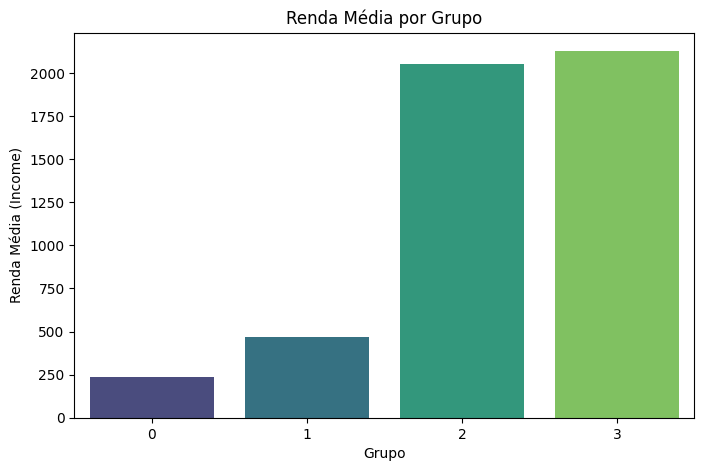

In [34]:
renda_media = df.groupby('Grupo')['Income'].mean().reset_index()
display(renda_media)

# Gráfico de barras da renda média
plt.figure(figsize=(8, 5))
sns.barplot(x='Grupo', y='Income', data=renda_media, palette='viridis')
plt.title('Renda Média por Grupo')
plt.xlabel('Grupo')
plt.ylabel('Renda Média (Income)')
plt.show()

## 7. Visualização Gráfica com PCA
Como temos muitas colunas, usamos a Análise de Componentes Principais (PCA) para reduzir os dados a 2 dimensões e conseguir plotar os grupos em um gráfico de dispersão.

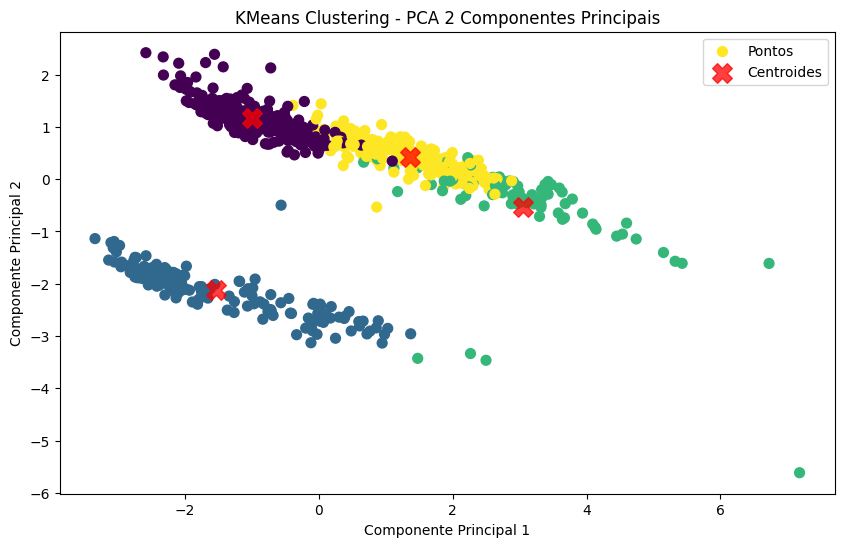

In [35]:
# Reduzindo para 2 componentes
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_normalizado)

# Extraindo e transformando os centroides
centroides = kmeans.cluster_centers_
centroides_pca = pca.transform(centroides)

# Plotando os resultados
plt.figure(figsize=(10, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans.labels_, s=50, cmap='viridis', label="Pontos")
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', s=200, alpha=0.75, marker='X', label="Centroides")
plt.title('KMeans Clustering - PCA 2 Componentes Principais')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()